In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.cluster import AgglomerativeClustering

In [2]:
df = pd.read_csv('data/Libra_node_features.csv')


In [30]:


# Assume 'hdbscan_labels' contains the labels from HDBSCAN, and 'data' is the original data
# Get unique clusters
unique_clusters = np.unique(df['cluster'])

# Calculate centroids of the clusters
centroids = np.array([df[df['cluster'] == cluster].mean(axis=0) for cluster in unique_clusters])

# Apply Agglomerative Clustering on the centroids
agg_cluster = AgglomerativeClustering(n_clusters=4)
new_labels = agg_cluster.fit_predict(centroids)

# Map the new labels back to the original data
final_labels = np.array([new_labels[unique_clusters.tolist().index(cluster)] for cluster in df['cluster']])
df['new_label'] = final_labels

In [31]:
df['new_label'].value_counts()

new_label
0    143712
3    136756
2    103341
1      1291
Name: count, dtype: int64

In [42]:
mask = df['new_label']==0
df[mask] 

,Id,in_degree,out_degree,in_strength_total,out_strength_total,in_strength_count,out_strength_count,cluster,new_label
0,0,0,4,0.00,41160.00,0,8,-1,0
1,349867,10,7,74689.61,78707.13,18,27,-1,0
2,351343,3,12,15750.00,43547.90,7,35,-1,0
3,350363,16,21,226726.80,230196.62,33,60,-1,0
4,349658,11,34,272574.00,254142.26,55,100,-1,0
...,...,...,...,...,...,...,...,...,...
385084,150506,1,0,282500.00,0.00,1,0,-1,0
385091,146087,1,0,214994.00,0.00,1,0,-1,0
385093,385074,1,1,11000.00,11000.00,2,2,-1,0
385094,309311,1,0,11000.00,0.00,2,0,-1,0


In [32]:
len(df)

385100

<Axes: >

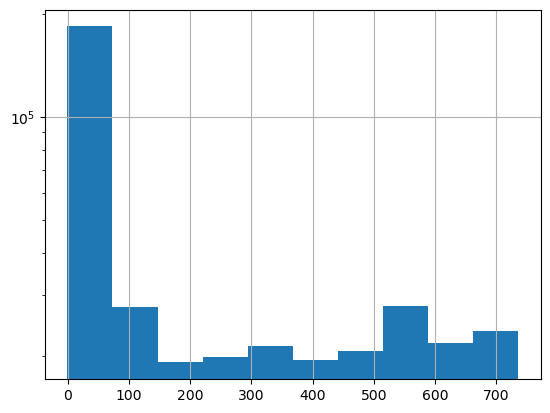

In [11]:
df['cluster'].hist(log=True)

In [13]:
mask = df['cluster'] == 200
df[mask]

,Id,in_degree,out_degree,in_strength_total,out_strength_total,in_strength_count,out_strength_count,cluster
3236,1976,0,1,0.0,1409.98,0,2,200
4554,2865,0,1,0.0,1412.02,0,2,200
6418,4229,0,1,0.0,1400.00,0,2,200
6701,4443,0,1,0.0,1391.63,0,2,200
7419,4961,0,1,0.0,1395.11,0,2,200
...,...,...,...,...,...,...,...,...
210296,333605,0,1,0.0,1400.00,0,2,200
213232,344141,0,1,0.0,1403.91,0,2,200
229511,348359,0,1,0.0,1406.16,0,2,200
312781,371649,0,1,0.0,1400.00,0,2,200


C:\Users\Longtao\AppData\Local\Temp\ipykernel_21272\2023699882.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_pca.groupby("cluster").apply(lambda x: x.sample(n=200, random_state=42) if len(x) > 200 else x).reset_index(drop=True)


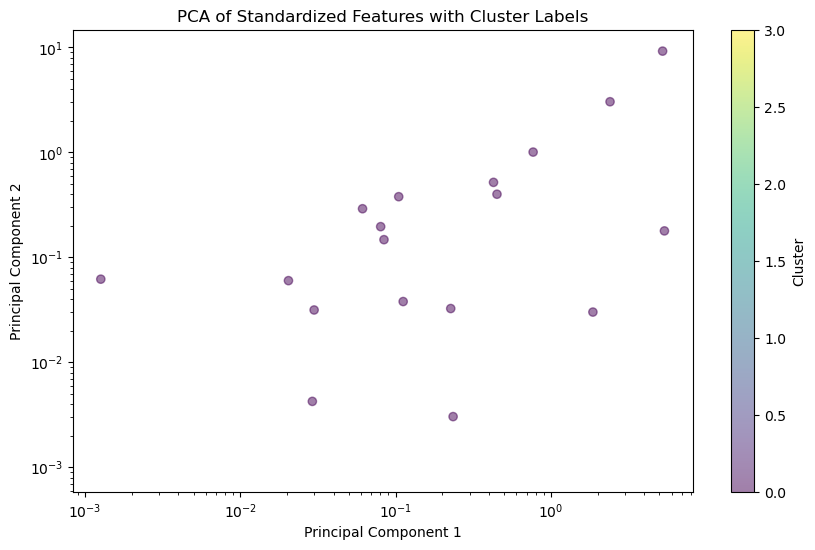

In [37]:
features = ["in_degree", "out_degree", "in_strength_total", "out_strength_total", "in_strength_count", "out_strength_count"]
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)


# Applying PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])

# Adding the cluster information to the PCA result
df_pca["cluster"] = df["new_label"]
df_sampled = df_pca.groupby("cluster").apply(lambda x: x.sample(n=200, random_state=42) if len(x) > 200 else x).reset_index(drop=True)

# Plotting the PCA result with cluster labels
plt.figure(figsize=(10, 6))
plt.scatter(df_sampled["PC1"], df_sampled["PC2"], c=df_sampled["cluster"], cmap='viridis',alpha=0.5)
plt.title("PCA of Standardized Features with Cluster Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.xscale('log')
plt.yscale('log')
plt.colorbar(label='Cluster')
plt.show()

In [79]:
df = df.sort_values(by=['in_strength_total'],ascending=False)

In [80]:
total = df['in_strength_total'].sum()
threshold = 0.8*total

In [81]:
sort_df = df.sort_values(by=['in_strength_total'],ascending=False)
sort_df['cumulative_sum'] = sort_df['in_strength_total'].cumsum()


In [82]:
# Step 3: Select rows where the cumulative sum exceeds the threshold
df_selected = sort_df[sort_df['cumulative_sum'] < threshold]


In [83]:
df_selected

,Id,in_degree,out_degree,in_strength_total,out_strength_total,in_strength_count,out_strength_count,cluster,new_label,cumulative_sum
733,345064,443,291,4.837828e+08,3.334661e+07,1298,626,-1,0,4.837828e+08
459,379687,1158,48818,2.825604e+08,2.741387e+08,2148,107774,-1,0,7.663432e+08
213480,159075,10,0,8.631693e+07,0.000000e+00,14,0,-1,0,8.526601e+08
190573,277357,5,1,6.304983e+07,1.303288e+05,10,2,-1,0,9.157100e+08
2032,348672,360,218,6.269150e+07,6.314573e+07,1190,521,-1,0,9.784015e+08
...,...,...,...,...,...,...,...,...,...,...
303483,294255,2,0,2.260519e+05,0.000000e+00,5,0,-1,0,1.120138e+10
901,379704,3,10,2.259861e+05,1.779770e+05,10,33,-1,0,1.120160e+10
357324,249297,1,0,2.259860e+05,0.000000e+00,6,0,-1,0,1.120183e+10
256115,351956,2,9,2.257000e+05,1.694971e+05,28,24,-1,0,1.120206e+10


In [66]:
total

14002863782.26

In [67]:
len(df)

385100

In [88]:
df['in_strength_count'].mean()

4.724822124123604

In [89]:
df_selected['in_strength_count'].mean()

130.29408020369192